In [11]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import requests

# URL da API do GitHub para listar o conteúdo da pasta
api_url = "https://api.github.com/repos/transparencia-mg/ses_violencia_contra_mulher/contents/dataset/data"

# Faz a requisição para obter a lista de arquivos
response = requests.get(api_url)
files = response.json()

df_list = []

# Loop por todos os arquivos retornados pela API
for file in files:
    # Filtra apenas os arquivos que terminam em .csv
    if file["name"].endswith(".csv"):
        raw_url = file["download_url"]
        print(f"Lendo: {file['name']}...")

        # Lê o CSV direto da URL RAW do GitHub
        temp_df = pd.read_csv(raw_url, sep=";")  # Cheque o separador (geralmente ';' ou ',')
        df_list.append(temp_df)

# Consolida todos os anos em um único DataFrame
df_completo = pd.concat(df_list, ignore_index=True)

print(f"Sucesso! Total de linhas: {len(df_completo)}")

Lendo: dados_violencia_mulheres_ses_2010.csv...
Lendo: dados_violencia_mulheres_ses_2011.csv...
Lendo: dados_violencia_mulheres_ses_2012.csv...
Lendo: dados_violencia_mulheres_ses_2013.csv...
Lendo: dados_violencia_mulheres_ses_2014.csv...
Lendo: dados_violencia_mulheres_ses_2015.csv...
Lendo: dados_violencia_mulheres_ses_2016.csv...
Lendo: dados_violencia_mulheres_ses_2017.csv...
Lendo: dados_violencia_mulheres_ses_2018.csv...
Lendo: dados_violencia_mulheres_ses_2019.csv...
Lendo: dados_violencia_mulheres_ses_2020.csv...
Lendo: dados_violencia_mulheres_ses_2021.csv...
Lendo: dados_violencia_mulheres_ses_2022.csv...
Lendo: dados_violencia_mulheres_ses_2023.csv...
Lendo: dados_violencia_mulheres_ses_2024.csv...
Lendo: dados_violencia_mulheres_ses_2025.csv...
Lendo: dados_violencia_mulheres_ses_2026.csv...
Sucesso! Total de linhas: 518861


In [12]:
# Salva o DataFrame consolidado na mesma pasta do projeto
df_completo.to_csv("dados_consolidados.csv", sep=";", index=False, encoding="utf-8-sig")

In [13]:
# Inspecionando o dataset 
df_completo = pd.read_csv("dados_consolidados.csv", sep=";")
display(df_completo)

,dt_notific,dt_nasc,nu_idade_n,cs_sexo,cs_raca,id_mn_resi,local_ocor,out_vezes,les_autop,viol_fisic,viol_psico,viol_sexu,num_envolv,autor_sexo,orient_sex,ident_gen
0,2010-08-03,1937-11-02,72,Feminino,Parda,Governador Valadares,Residencia,Sim,Não,Sim,Sim,Não,Um,Masculino,NaN,NaN
1,2010-02-07,1992-04-30,17,Feminino,Parda,Montes Claros,Residencia,Ignorado,Não,Sim,Sim,NaN,Um,Masculino,NaN,NaN
2,2010-06-28,2003-04-07,7,Feminino,Ignorado,Governador Valadares,Ignorado,Ignorado,Não,Não,Sim,Sim,Um,Masculino,NaN,NaN
3,2010-01-07,1963-05-07,46,Feminino,Parda,São José do Goiabal,Residencia,Ignorado,NaN,Não,Não,Não,Um,Feminino,NaN,NaN
4,2010-05-20,1917-08-01,92,Feminino,Branca,Jaboticatubas,Residencia,Sim,NaN,Não,Não,Não,Dois ou mais,Masculino,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518856,2026-08-15,2004-02-05,"22,0",Feminino,Parda,Belo Vale,Residencia,Não,Não,Sim,Sim,Não,Um,Masculino,Heterossexual,Não se aplica
518857,2026-08-15,2002-06-15,"24,0",Feminino,Parda,Belo Vale,Residencia,Não,Sim,Não,Não,Não,Um,Feminino,Heterossexual,Não se aplica
518858,2026-09-01,NaN,"46,0",Feminino,Parda,Belo Vale,Residencia,Sim,Não,Sim,Sim,Não,Um,Masculino,Heterossexual,Não se aplica
518859,2026-09-07,2003-06-16,"23,0",Feminino,Branca,Belo Vale,Residencia,Ignorado,Sim,Não,Não,Não,Um,Feminino,Heterossexual,Não se aplica


In [14]:
# Fazendo a limpeza de dados
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Definindo o estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 1. Converter dt_notific para datetime
df_completo["dt_notific"] = pd.to_datetime(
    df_completo["dt_notific"], errors="coerce"
)
df_completo["ano_notific"] = df_completo["dt_notific"].dt.year

# 2. Converter a coluna de idade para numerico
df_completo["nu_idade_n"] = (
    df_completo["nu_idade_n"]
    .astype(str)
    .str.replace(",", ".")
    .astype(float)
)

# 3. Limpando valores em string (remover espaços em branco)
string_cols = [
    "local_ocor",
    "out_vezes",
    "viol_fisic",
    "viol_psico",
    "viol_sexu",
    "autor_sexo",
]
for col in string_cols:
    if col in df_completo.columns:
        df_completo[col] = df_completo[col].astype(str).str.strip()

# Re-inspecionando as primeiras linhas de dados
df_completo.head(10)

,dt_notific,dt_nasc,nu_idade_n,cs_sexo,cs_raca,id_mn_resi,local_ocor,out_vezes,les_autop,viol_fisic,viol_psico,viol_sexu,num_envolv,autor_sexo,orient_sex,ident_gen,ano_notific
0,2010-08-03,1937-11-02,72.0,Feminino,Parda,Governador Valadares,Residencia,Sim,Não,Sim,Sim,Não,Um,Masculino,NaN,NaN,2010
1,2010-02-07,1992-04-30,17.0,Feminino,Parda,Montes Claros,Residencia,Ignorado,Não,Sim,Sim,NaN,Um,Masculino,NaN,NaN,2010
2,2010-06-28,2003-04-07,7.0,Feminino,Ignorado,Governador Valadares,Ignorado,Ignorado,Não,Não,Sim,Sim,Um,Masculino,NaN,NaN,2010
3,2010-01-07,1963-05-07,46.0,Feminino,Parda,São José do Goiabal,Residencia,Ignorado,NaN,Não,Não,Não,Um,Feminino,NaN,NaN,2010
4,2010-05-20,1917-08-01,92.0,Feminino,Branca,Jaboticatubas,Residencia,Sim,NaN,Não,Não,Não,Dois ou mais,Masculino,NaN,NaN,2010
5,2010-07-09,2010-01-19,0.0,Feminino,Branca,Pouso Alegre,Ignorado,Ignorado,Não,Sim,Não,Não,Um,Feminino,NaN,NaN,2010
6,2010-02-09,1999-06-06,10.0,Feminino,Branca,Bambuí,Residencia,Ignorado,Não,Sim,Não,Não,Um,Masculino,NaN,NaN,2010
7,2010-01-23,1955-01-30,54.0,Feminino,Ignorado,Contagem,Residencia,Ignorado,Não,Sim,Não,Não,Ignorado,Ignorado,NaN,NaN,2010
8,2010-03-01,1980-09-08,29.0,Feminino,Branca,Patos de Minas,Ignorado,Não,NaN,Sim,Não,Não,Ignorado,Ignorado,NaN,NaN,2010
9,2010-02-07,1985-08-25,24.0,Feminino,Parda,Várzea da Palma,Via pública,Não,Não,Sim,NaN,NaN,Um,Feminino,NaN,NaN,2010


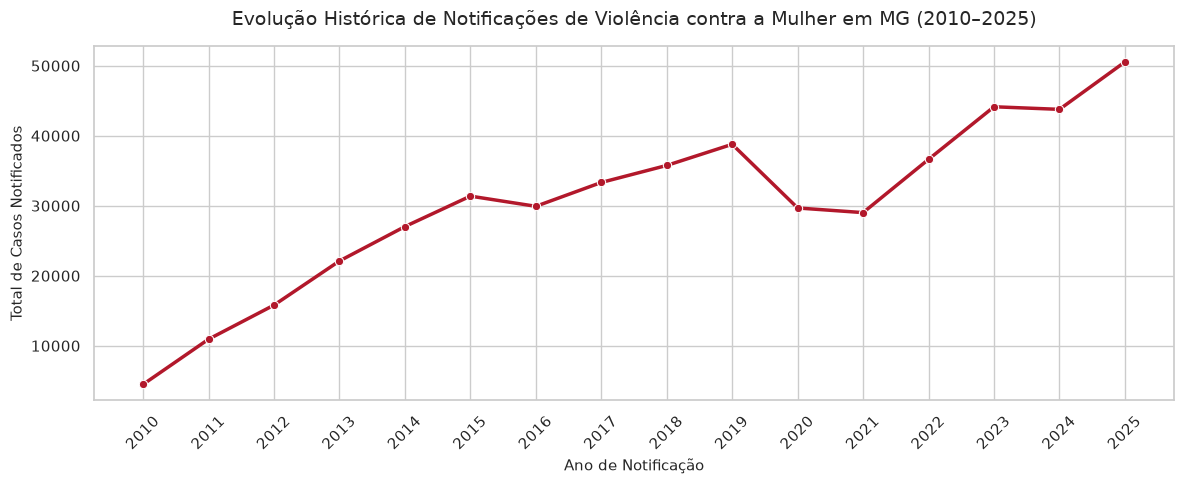

In [15]:
# Gráfico 1: Evolução Temporal dos Casos
ocorrencias_por_ano = (
    df_completo[df_completo["ano_notific"].between(2010, 2025)]
    ["ano_notific"]
    .value_counts()
    .sort_index()
    .reset_index()
)
ocorrencias_por_ano.columns = ["Ano", "Total_Ocorrencias"]

plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=ocorrencias_por_ano,
    x="Ano",
    y="Total_Ocorrencias",
    marker="o",
    color="#b2182b",
    linewidth=2.5,
)

plt.title(
    "Evolução Histórica de Notificações de Violência contra a Mulher em MG"
    " (2010–2025)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Ano de Notificação", fontsize=11)
plt.ylabel("Total de Casos Notificados", fontsize=11)
plt.xticks(ocorrencias_por_ano["Ano"], rotation=45)

# Salva a imagem em alta resolução para exibição em TV/Telas
plt.tight_layout()
plt.savefig("01_evolucao_historica_casos.png", dpi=300, bbox_inches="tight")
plt.show()

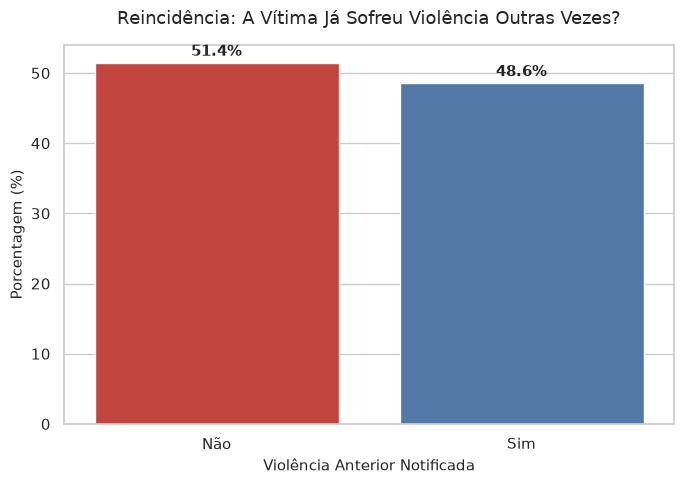

In [17]:
# Gráfico 2: Histórico de Reincidência de Agressão
reincidencia_df = df_completo[
    df_completo["out_vezes"].isin(["Sim", "Não"])
]["out_vezes"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=reincidencia_df.index,
    y=reincidencia_df.values,
    palette=["#d73027", "#4575b4"],
)

plt.title(
    "Reincidência: A Vítima Já Sofreu Violência Outras Vezes?",
    fontsize=13,
    pad=15,
)
plt.ylabel("Porcentagem (%)", fontsize=11)
plt.xlabel("Violência Anterior Notificada", fontsize=11)

# Adiciona a porcentagem exata no topo de cada barra
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontsize=11,
        weight="bold",
    )

# Salva a imagem em alta resolução
plt.tight_layout()
plt.savefig("02_taxa_reincidencia_violencia.png", dpi=300, bbox_inches="tight")
plt.show()

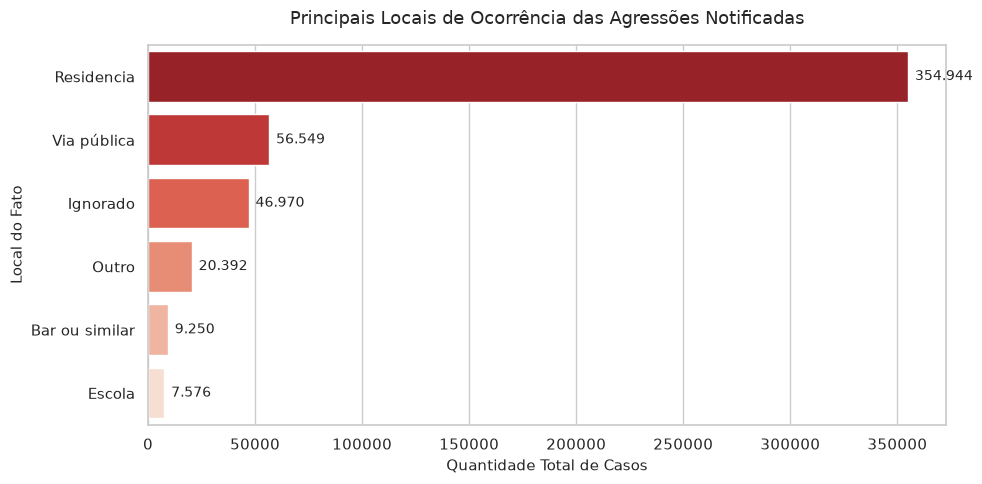

In [19]:
# Gráfico 3: Distribuição por Local da Agressão
locais_df = (
    df_completo["local_ocor"]
    .replace({"NaN": "Ignorado", "nan": "Ignorado"})
    .value_counts()
    .head(6)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    y=locais_df.index, x=locais_df.values, palette="Reds_r"
)

plt.title(
    "Principais Locais de Ocorrência das Agressões Notificadas",
    fontsize=13,
    pad=15,
)
plt.xlabel("Quantidade Total de Casos", fontsize=11)
plt.ylabel("Local do Fato", fontsize=11)

# Formata os números no final de cada barra com ponto de milhar
for p in ax.patches:
    largura = p.get_width()
    ax.annotate(
        f"{largura:,.0f}".replace(",", "."),
        (largura, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=10,
    )

# Salva a imagem em alta resolução
plt.tight_layout()
plt.savefig("03_locais_ocorrencia.png", dpi=300, bbox_inches="tight")
plt.show()